In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1) Load cleaned data
df = pd.read_csv("cleaned_formatting_data.csv")  # ← update path if needed

# 2) Map your target to 0/1
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# 3) Drop any truly non-predictive columns (IDs, cluster info, etc.)
to_drop = [
    'Name', 'Email', 'Customer ID', 'Transaction Date', 'IP Address',
    'POS_Transaction_ID', 'Zip Code', 'Product Name', 'Language',
    'Store_Location_City', 'Store_Location_Country',
    'Delivery_Location_City', 'Delivery_Location_Country',
    'Referral Source', 'Cluster', 'Customer_Type'
]
df.drop(columns=to_drop, errors='ignore', inplace=True)

# 4) Train/test split
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5) Build preprocessing pipeline
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
], remainder='drop')  # drop anything else

# 6) Fit & transform training data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# 7) Mutual-information feature selection
total_feats     = X_train_proc.shape[1]
discrete_flags  = [True]*len(categorical_cols) + [False]*(total_feats-len(categorical_cols))

mi_scores = mutual_info_classif(X_train_proc, y_train, discrete_features=discrete_flags)

# get feature names in the same order as the transformed array
feat_names = (
    preprocessor.named_transformers_['cat']
                .get_feature_names_out(categorical_cols).tolist()
  + numerical_cols
)

mi_df      = pd.DataFrame({'feature': feat_names, 'mi_score': mi_scores})
top_10     = mi_df.nlargest(10, 'mi_score')['feature'].tolist()
print("Top 10 predictive features:\n", top_10)

# 8) Subset to top features & train RandomForest
X_tr_sel = pd.DataFrame(X_train_proc, columns=feat_names)[top_10]
X_te_sel = pd.DataFrame(X_test_proc,  columns=feat_names)[top_10]

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_tr_sel, y_train)

# 9) Evaluate
y_pred  = model.predict(X_te_sel)
y_proba = model.predict_proba(X_te_sel)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active','Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

Top 10 predictive features:
 ['Order_Fulfillment_Time', 'Bounce Rate', 'Chargebacks', 'Clickstream Data', 'Location', 'source', 'Return_Rate', 'Product Price', 'Intent Stage', 'Product_Views']

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       539
     Churned       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train_selected, y_train, cv=5)
print("Cross-Validation Scores:", scores)

Cross-Validation Scores: [1. 1. 1. 1. 1.]


In [ ]:
print("Top Features:\n", top_features)

Top Features:
 ['Order_Fulfillment_Time', 'Chargebacks', 'Bounce Rate', 'Number of Chargebacks', 'Clickstream Data', 'Location', 'source', 'Product Price', 'Return_Rate', 'Product_Views']


In [ ]:
mi_df

,feature,mi_score
0,Location,0.124791
1,Gender,0.027016
2,Payment Method,0.024794
3,Clickstream Data,0.126846
4,Search Query,0.075298
...,...,...
60,Ad_Clicks,0.101354
61,Coupon_Code_Usage,0.069700
62,Repeat_Purchase_Decline,0.108521
63,Return_Rate,0.123494


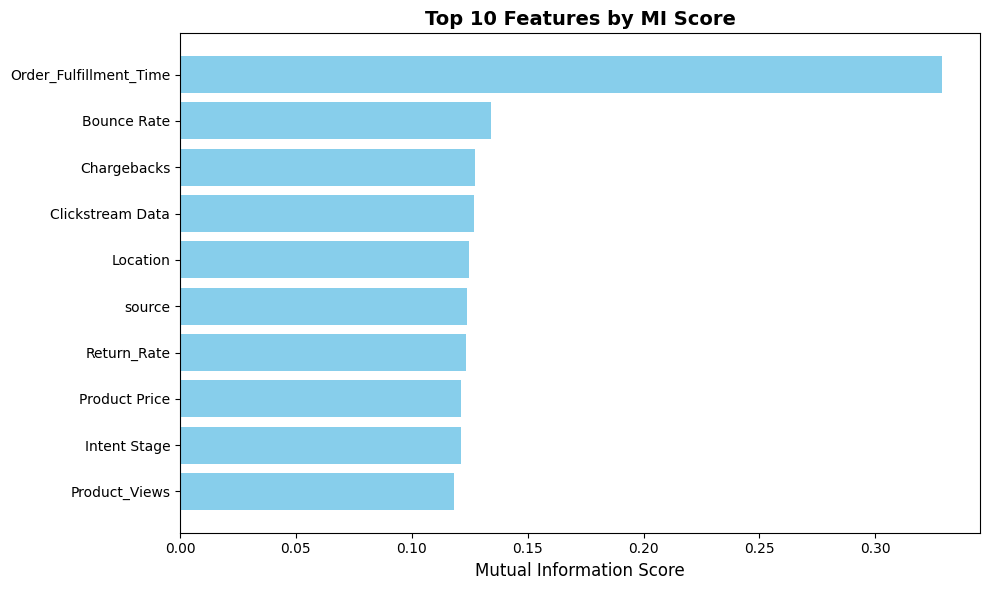

In [ ]:
import matplotlib.pyplot as plt

# 1. Filter MI scores for just the top features
top_mi_scores = (
    mi_df[mi_df['feature'].isin(top_10)]
    .sort_values('mi_score', ascending=False)
)

# 2. Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_mi_scores['feature'], top_mi_scores['mi_score'], color='skyblue')
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Top 10 Features by MI Score', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()   # highest score at the top
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

Top 10 Features by MI Score:
                            Feature  MI_Score
33     cat__Order_Fulfillment_Time  0.693147
63                  num__Ad_Clicks  0.539802
4            cat__Clickstream Data  0.537069
59         num__Purchase_Frequency  0.503167
60              num__Product_Views  0.500826
62         num__Return_Refund_Rate  0.499408
0                    cat__Location  0.471786
30     cat__Delivery_Location_City  0.452952
31  cat__Delivery_Location_Country  0.442194
45               num__Intent Stage  0.423266


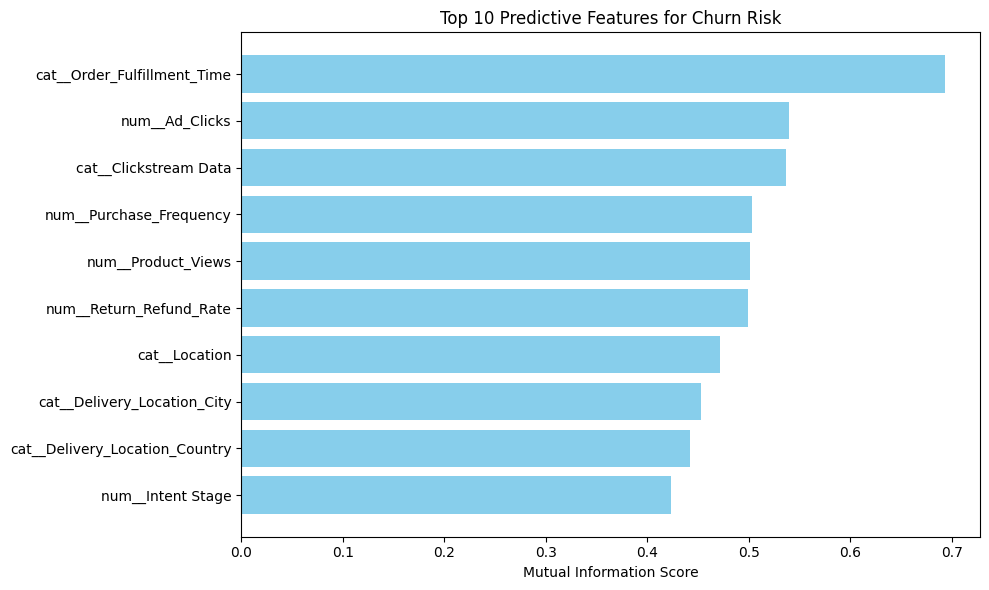


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Load cleaned data
df = pd.read_csv("cleaned_formatting_data.csv")

# 2. TARGET VALIDATION & MAPPING
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# 3. DROP LEAKAGE CANDIDATES & NON-PREDICTIVES
leakage_candidates = [
    'Subscription Cancelled', 'Churn Reason', 'Return_Flag',
    'Churned', 'Last Purchase Date', 'Customer ID'
]
non_predictive = [
    'Name', 'Email', 'Transaction Date', 'IP Address',
    'POS_Transaction_ID', 'Zip Code', 'Product Name'
]
df.drop(columns=leakage_candidates + non_predictive, errors='ignore', inplace=True)

# 4. SPLIT DATA
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. PREPROCESSING PIPELINE
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='drop'
)

# 6. TRANSFORM TRAINING DATA
X_train_proc = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# 7. HANDLE CLASS IMBALANCE WITH SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

# 8. MUTUAL INFORMATION FEATURE SELECTION
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_res, y_train_res, discrete_features=discrete_mask)
mi_df     = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})

# Pick top 10 features
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("Top 10 Features by MI Score:\n", mi_df.nlargest(10, 'MI_Score'))

# 9. SUBSET BOTH TRAIN & TEST TO TOP FEATURES
X_train_sel = pd.DataFrame(X_train_res, columns=feature_names)[top_features]

# Transform and subset test data
X_test_proc = preprocessor.transform(X_test)
X_test_sel  = pd.DataFrame(X_test_proc, columns=feature_names)[top_features]

# 10. VISUALIZE TOP FEATURES
top_mi_scores = mi_df[mi_df['Feature'].isin(top_features)].sort_values('MI_Score', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(top_mi_scores['Feature'], top_mi_scores['MI_Score'], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Predictive Features for Churn Risk')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 11. MODEL TRAINING
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_sel, y_train_res)

# 12. EVALUATION ON TEST SET
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")


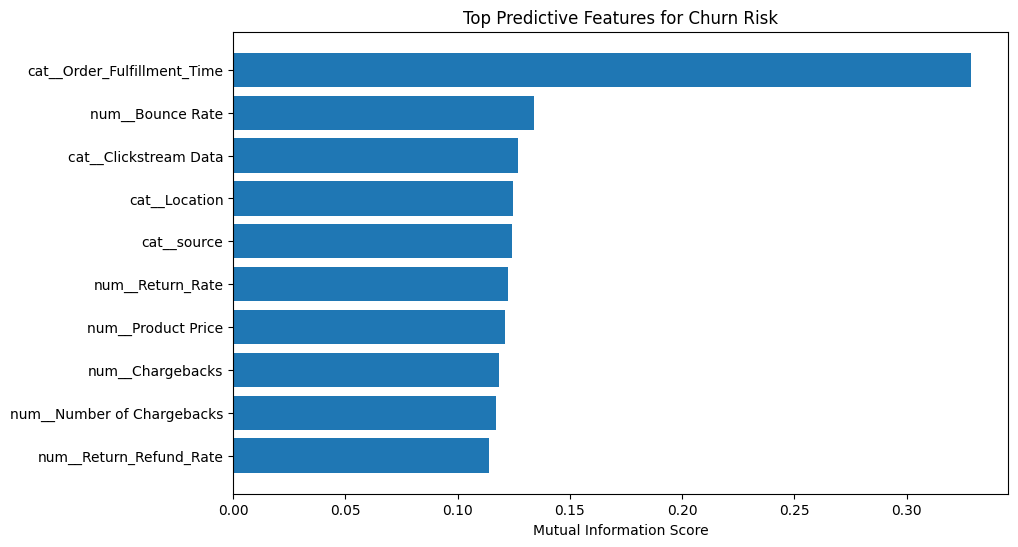


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


In [ ]:
# ========================================================================
# 1. DATA PREPROCESSING
# ========================================================================
# Preprocess data FIRST
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get valid feature names
feature_names = preprocessor.get_feature_names_out()

# ========================================================================
# 2. FEATURE SELECTION (BEFORE SMOTE)
# ========================================================================
# Compute MI scores on original training data (before resampling)
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)

# Create MI DataFrame and select top 10 features
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()

# ========================================================================
#  VISUALIZE MI SCORES
# ========================================================================
plt.figure(figsize=(10, 6))
plt.barh(top_features, mi_df.nlargest(10, 'MI_Score')['MI_Score'], color='#1f77b4')
plt.xlabel('Mutual Information Score')
plt.title('Top Predictive Features for Churn Risk')
plt.gca().invert_yaxis()
plt.show()
# ========================================================================
# 3. BALANCE CLASSES WITH SMOTE (ON SELECTED FEATURES)
# ========================================================================
# Select top features from processed data
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_selected = pd.DataFrame(X_test_processed, columns=feature_names)[top_features]

# Apply SMOTE to selected features
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# ========================================================================
# 4. MODEL TRAINING & EVALUATION
# ========================================================================
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_res, y_train_res)

# Predict using the SAME selected features
y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

Top 10 Features by MI Score:
                         Feature  MI_Score
34  cat__Order_Fulfillment_Time  0.328730
36             num__Bounce Rate  0.134346
62           num__Product_Views  0.127872
4         cat__Clickstream Data  0.126846
0                 cat__Location  0.124791
20                  cat__source  0.124020
52   num__Number of Chargebacks  0.122693
51             num__Chargebacks  0.122597
68             num__Return_Rate  0.122164
45     num__Consideration Stage  0.120855


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:27:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


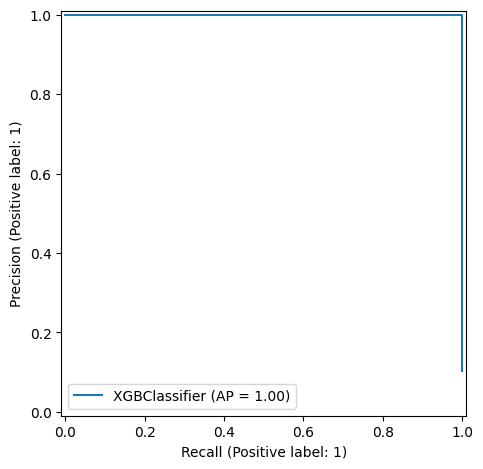


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


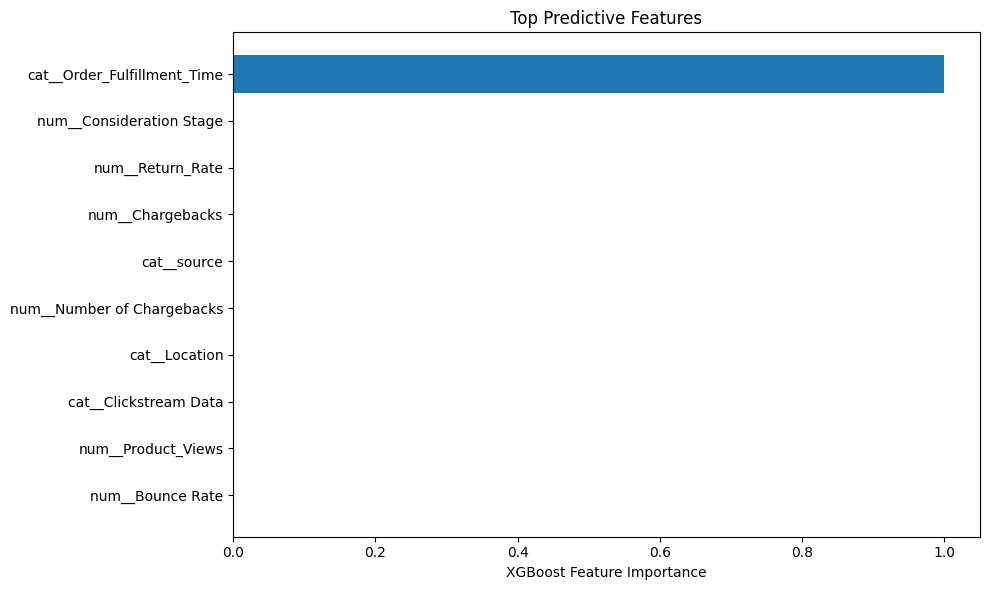

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE

# ========================================================================
# 1. LOAD CLEANED DATA & MAP TARGET
# ========================================================================
df = pd.read_csv("cleaned_formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# ========================================================================
# 2. DROP NON-PREDICTIVE / LEAKAGE COLUMNS
# ========================================================================
to_drop = [
    'Name', 'Email', 'Customer ID', 'Transaction Date',
    'IP Address', 'POS_Transaction_ID', 'Zip Code',
    'Order_ID', 'First Interaction Date', 'Product Name'
]
df.drop(columns=to_drop, errors='ignore', inplace=True)

# ========================================================================
# 3. TRAIN/TEST SPLIT
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========================================================================
# 4. PREPROCESSING PIPELINE
# ========================================================================
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# ========================================================================
# 5. FEATURE SELECTION (MUTUAL INFORMATION)
# ========================================================================
# a) Fit & transform training data
X_train_proc = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# b) Compute MI scores
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_proc, y_train, discrete_features=discrete_mask)

# c) Pick top 10 features
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("Top 10 Features by MI Score:\n", mi_df.nlargest(10, 'MI_Score'))

# ========================================================================
# 6. SUBSET & BALANCE TRAINING DATA
# ========================================================================
# a) Subset train & test to top features
X_train_sel = pd.DataFrame(X_train_proc, columns=feature_names)[top_features]
X_test_proc = preprocessor.transform(X_test)
X_test_sel  = pd.DataFrame(X_test_proc, columns=feature_names)[top_features]

# b) Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

# ========================================================================
# 7. TRAIN XGBOOST
# ========================================================================
# Compute scale_pos_weight to counter imbalance
scale_pos_weight = (
    len(y_train_res[y_train_res == 0])
    / len(y_train_res[y_train_res == 1])
)

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_res, y_train_res)

# ========================================================================
# 8. EVALUATION & VISUALIZATION
# ========================================================================
# a) Predictions & probabilities
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:, 1]

# b) Precision-recall curve
PrecisionRecallDisplay.from_estimator(model, X_test_sel, y_test)
plt.tight_layout()
plt.show()

# c) Classification report & AUC-ROC
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

# d) Feature importance plot
plt.figure(figsize=(10, 6))
idx_sorted = np.argsort(model.feature_importances_)
plt.barh(
    np.array(top_features)[idx_sorted],
    model.feature_importances_[idx_sorted]
)
plt.xlabel("XGBoost Feature Importance")
plt.title("Top Predictive Features")
plt.tight_layout()
plt.show()


Top 10 features:
                         Feature  MI_Score
34  cat__Order_Fulfillment_Time  0.328730
36             num__Bounce Rate  0.135079
4         cat__Clickstream Data  0.126846
51             num__Chargebacks  0.126470
0                 cat__Location  0.124791
20                  cat__source  0.124020
52   num__Number of Chargebacks  0.121959
50           num__Product Price  0.121829
68             num__Return_Rate  0.121755
62           num__Product_Views  0.121053
=== XGBoost Results ===


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:30:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.000

=== Random Forest Results ===
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.000



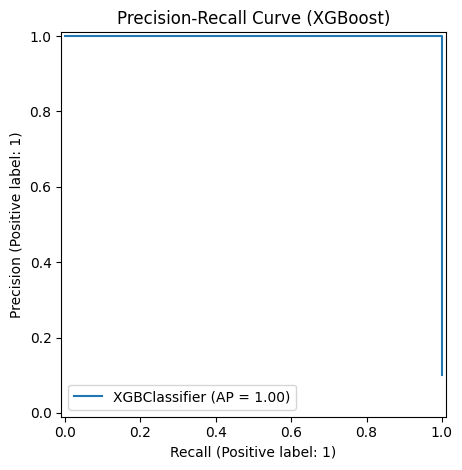

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score, PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1) Load and prepare data
df = pd.read_csv("cleaned_formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# 2) Drop non-predictive/leakage columns
to_drop = [
    'Name', 'Email', 'Customer ID', 'Transaction Date', 'IP Address',
    'POS_Transaction_ID', 'Zip Code', 'Order_ID', 'First Interaction Date',
    'Product Name', 'Cluster', 'Customer_Type'
]
df.drop(columns=to_drop, errors='ignore', inplace=True)

# 3) Train/test split
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4) Preprocessing
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols),
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# 5) Mutual information feature selection
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_proc, y_train, discrete_features=discrete_mask)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("Top 10 features:\n", mi_df.nlargest(10, 'MI_Score'))

# 6) Subset and balance training data
X_train_sel = pd.DataFrame(X_train_proc, columns=feature_names)[top_features]
X_test_proc = preprocessor.transform(X_test)
X_test_sel  = pd.DataFrame(X_test_proc, columns=feature_names)[top_features]

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

# 7) Define training/evaluation helper
def train_evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    print(classification_report(y_te, y_pred, target_names=['Low Risk','High Risk']))
    prf = precision_recall_fscore_support(y_te, y_pred, average='weighted')[:3]
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else None
    return prf, auc

# 8) Initialize models
scale_pos_weight = len(y_train_res[y_train_res==0]) / len(y_train_res[y_train_res==1])
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# 9) Train & evaluate XGBoost
print("=== XGBoost Results ===")
(xgb_pr, xgb_rc, xgb_f1), xgb_auc = train_evaluate_model(
    xgb_model, X_train_res, y_train_res, X_test_sel, y_test
)
print(f"AUC-ROC: {xgb_auc:.3f}\n")

# 10) Train & evaluate Random Forest
print("=== Random Forest Results ===")
(rf_pr, rf_rc, rf_f1), rf_auc = train_evaluate_model(
    rf_model, X_train_res, y_train_res, X_test_sel, y_test
)
print(f"AUC-ROC: {rf_auc:.3f}\n")

# 11) Plot Precision-Recall curve for XGBoost
PrecisionRecallDisplay.from_estimator(xgb_model, X_test_sel, y_test)
plt.title("Precision-Recall Curve (XGBoost)")
plt.tight_layout()
plt.show()


In [ ]:
# ========================================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# ========================================================================
# 2. DATA PROCESSING & FEATURE SELECTION
# ========================================================================
# Load and clean data
df = pd.read_csv("cleaned_formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})




# Clean non-predictive columns
non_predictive = ['Name', 'Email', 'Customer ID', 'Transaction Date',
                 'IP Address', 'POS_Transaction_ID', 'Zip Code']
df = df.drop(columns=non_predictive, errors='ignore')

# ========================================================================
# DATA SPLITTING
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# After original train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Separate test classes
minority_mask = y_test == 1
X_test_min = X_test[minority_mask]
y_test_min = y_test[minority_mask]
X_test_maj = X_test[~minority_mask]
y_test_maj = y_test[~minority_mask]

# Downsample majority
X_test_maj_down, y_test_maj_down = resample(
    X_test_maj,
    y_test_maj,
    n_samples=len(X_test_min),  # Match minority count
    random_state=42
)

# Combine and shuffle
X_test_balanced = pd.concat([X_test_min, X_test_maj_down])
y_test_balanced = pd.concat([y_test_min, y_test_maj_down])
shuffled_idx = np.random.permutation(len(X_test_balanced))
X_test_balanced = X_test_balanced.iloc[shuffled_idx]
y_test_balanced = y_test_balanced.iloc[shuffled_idx]



# Preprocessing
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# Feature selection
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
discrete_mask = [name.startswith('cat__') for name in feature_names]

# Select top 10 features
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()

# Apply selection
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_balanced_selected = pd.DataFrame(preprocessor.transform(X_test_balanced), columns=feature_names)[top_features]

# Balance training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# ========================================================================
# 3. IMPROVED NEURAL NETWORK
# ========================================================================
def create_nn(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # Single loss function
        metrics=['AUC', 'Precision', 'Recall']
    )
    return model

# Train with class weights (not loss_weights)
class_weights = {0: 1, 1: 10}  # Penalize class 1 (churn) 10x more

# Train model
nn_model = create_nn(X_train_res.shape[1])
early_stopping = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history = nn_model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=0
)

# Evaluate
print("Neural Network Performance:")
y_pred_nn = (nn_model.predict(X_test_balanced_selected) > 0.5).astype(int)
print(classification_report(y_test_balanced, y_pred_nn))

# ========================================================================
# 4. ROBUST ENSEMBLE STACKING
# ========================================================================
# Base models
xgb = XGBClassifier(scale_pos_weight=5, eval_metric='logloss', use_label_encoder=False)
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1)

# Stacking with cross-validation
stack_model = StackingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Train and evaluate
stack_model.fit(X_train_res, y_train_res)
print("\nStacking Model Performance:")
y_pred_stack = stack_model.predict(X_test_balanced_selected)
print(classification_report(y_test_balanced, y_pred_stack))

# ========================================================================
# 5. FEATURE CONSISTENCY CHECK
# ========================================================================
# Verify feature alignment
train_features = set(X_train_res.columns)
test_features = set(X_test_balanced_selected.columns)
assert train_features == test_features, f"Feature mismatch! Missing: {train_features - test_features}, Extra: {test_features - train_features}"

Neural Network Performance:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        61
           1       0.97      1.00      0.98        61

    accuracy                           0.98       122
   macro avg       0.98      0.98      0.98       122
weighted avg       0.98      0.98      0.98       122


Stacking Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        61

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



In [ ]:
# ========================================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    make_scorer
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, callbacks

# ========================================================================
# 2. DATA LOADING & TARGET MAPPING
# ========================================================================
df = pd.read_csv("cleaned_formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# ========================================================================
# 3. DROP NON-PREDICTIVE / LEAKAGE COLUMNS
# ========================================================================
to_drop = [
    'Name', 'Email', 'Customer ID', 'Transaction Date',
    'IP Address', 'POS_Transaction_ID', 'Zip Code',
    'Order_ID', 'First Interaction Date', 'Product Name',
    'Cluster', 'Customer_Type'
]
df.drop(columns=to_drop, errors='ignore', inplace=True)

# ========================================================================
# 4. TRAIN/TEST SPLIT & BALANCED TEST SET
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Create balanced test set for evaluation
X_min = X_test[y_test == 1]
X_maj = X_test[y_test == 0].sample(n=len(X_min), random_state=42)
X_test_bal = pd.concat([X_min, X_maj])
y_test_bal = pd.concat([
    y_test[y_test == 1],
    y_test[y_test == 0].sample(n=len(X_min), random_state=42)
])

# ========================================================================
# 5. PREPROCESSING & FEATURE SELECTION
# ========================================================================
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Mutual Information for feature ranking
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_proc, y_train, discrete_features=discrete_mask)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})

# Select top 15 features
top_features = mi_df.nlargest(15, 'MI_Score')['Feature'].tolist()
print("Top 15 Features by MI Score:\n", mi_df.nlargest(15, 'MI_Score'))

# Subset train/test to top features
X_train_sel     = pd.DataFrame(X_train_proc, columns=feature_names)[top_features]
X_test_proc     = preprocessor.transform(X_test)
X_test_sel      = pd.DataFrame(X_test_proc, columns=feature_names)[top_features]
X_test_bal_proc = preprocessor.transform(X_test_bal)
X_test_bal_sel  = pd.DataFrame(X_test_bal_proc, columns=feature_names)[top_features]

# Balance the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

# ========================================================================
# 6. DEEP LEARNING MODEL (Keras)
# ========================================================================
def create_nn(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

nn_model = create_nn(X_train_res.shape[1])
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)

nn_model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=0
)

print("\nDeep Learning Performance on Balanced Test Set:")
y_proba_nn = nn_model.predict(X_test_bal_sel).ravel()
y_pred_nn  = (y_proba_nn > 0.5).astype(int)
print(classification_report(y_test_bal, y_pred_nn))

# ========================================================================
# 7. ENSEMBLE STACKING MODEL
# ========================================================================
scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist',
    random_state=42
)
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Fit base learners
xgb_model.fit(X_train_res, y_train_res)
rf_model.fit(X_train_res, y_train_res)

# Build stacking ensemble
stack_model = StackingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model)],
    final_estimator=RandomForestClassifier(random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)
stack_model.fit(X_train_res, y_train_res)

print("\nEnsemble Stacking Performance on Balanced Test Set:")
y_pred_stack = stack_model.predict(X_test_bal_sel)
print(classification_report(y_test_bal, y_pred_stack))

# ========================================================================
# 8. ADVANCED VISUALIZATIONS
# ========================================================================
# Precision-Recall Curves
plt.figure(figsize=(10, 6))
for name, mdl in [
    ('XGBoost', xgb_model),
    ('RandomForest', rf_model),
    ('NeuralNet', nn_model),
    ('Stacking', stack_model),
]:
    proba = mdl.predict_proba(X_test_bal_sel)[:, 1] if hasattr(mdl, "predict_proba") else mdl.predict(X_test_bal_sel).ravel()
    prec, rec, _ = precision_recall_curve(y_test_bal, proba)
    plt.plot(rec, prec, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importances: XGBoost vs. Neural Net
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=top_features).sort_values()
xgb_imp.plot(kind='barh', ax=axes[0], title='XGBoost Feature Importances')

# Neural Net permutation importance with AUC-ROC scorer
auc_scorer = make_scorer(roc_auc_score, needs_threshold=True)
perm = permutation_importance(
    nn_model,
    X_test_bal_sel,
    y_test_bal,
    n_repeats=5,
    random_state=42,
    scoring=auc_scorer
)
nn_imp = pd.Series(perm.importances_mean, index=top_features).sort_values()
nn_imp.plot(kind='barh', ax=axes[1], title='NN Permutation Importances')

plt.tight_layout()
plt.show()


Top 15 Features by MI Score:
                          Feature  MI_Score
34   cat__Order_Fulfillment_Time  0.328730
36              num__Bounce Rate  0.134515
4          cat__Clickstream Data  0.126846
51              num__Chargebacks  0.125279
0                  cat__Location  0.124791
20                   cat__source  0.124020
52    num__Number of Chargebacks  0.121923
50            num__Product Price  0.121794
68              num__Return_Rate  0.120769
46             num__Intent Stage  0.119969
44          num__Awareness Stage  0.116925
62            num__Product_Views  0.116115
45      num__Consideration Stage  0.115849
65                num__Ad_Clicks  0.113565
67  num__Repeat_Purchase_Decline  0.109137

Deep Learning Performance on Balanced Test Set:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        61

    accuracy                   

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:04:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
